In [54]:
import os
import sys

In [19]:
# get current working directory
os.getcwd()
# change directory
os.chdir('../')
os.getcwd()

'c:\\Users\\gtheis2\\git\\surfactant_project'

In [20]:
# Setup paths
base_dir = 'c:\\Users\\gtheis2\\git\\surfactant_project\\Graph-Transformers_org-2'
os.chdir(base_dir)
sys.path.append('src')

In [21]:
# Import your modules
from model import PharmHGT
from data import create_dataloader, MolGraphSet
import utils

In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os
import csv
import pandas as pd

In [23]:
# Model arguments
model_args = {
    'hid_dim': 384,
    'atom_dim': 55,
    'bond_dim': 14,
    'pharm_dim': 194,
    'reac_dim': 34,
    'depth': 3,
    'act': 'relu',
    'num_task': 1,
    "dropout": 0.4513056251287794
}

# Data arguments - using relative path as in original code
data_args = {
    'path': 'data/surfactant_data1/Split_70_20_10',  # Keep relative path as expected by create_dataloader
    'batch_size': 32,
    'target_names': ['logCMC'],
    'task': 'regression'
}
ramdom_seed = 42
# Try to create dataloaders
try:
    # First verify the files exist
    full_train_path = os.path.join(base_dir, data_args['path'], f'{ramdom_seed}_fold_0_train.csv')
    full_test_path = os.path.join(base_dir, data_args['path'], f'{ramdom_seed}_fold_0_test.csv')
    
    print(f"Checking if train file exists: {os.path.exists(full_train_path)}")
    print(f"Checking if test file exists: {os.path.exists(full_test_path)}")
    
    # Create dataloaders using original function
    trainloader = create_dataloader(data_args, f'{ramdom_seed}_fold_0_train.csv', shuffle=False)
    testloader = create_dataloader(data_args, f'{ramdom_seed}_fold_0_test.csv', shuffle=False)
    print("Successfully created dataloaders")
    
except Exception as e:
    print(f"Error creating dataloaders: {e}")
    print(f"Full train path: {full_train_path}")
    print(f"Full test path: {full_test_path}")
    raise

Checking if train file exists: True
Checking if test file exists: True
Successfully created dataloaders


In [24]:
# Load the model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = PharmHGT(model_args).to(device)

In [25]:
# # Before loading the state dict, print the model architectures
# print("Current model architecture:")
# print(model)
# print("\nSaved state dict keys:")
# print(checkpoint['model_state_dict'].keys())

In [26]:
# Load saved model
model_folder = 'surfactant_model_data1_newSplit70_20_10_plot_opt_R7/seed_42/fold_0'
model_path = os.path.join(base_dir, 'models', model_folder, 'best_fold0.pt')

if os.path.exists(model_path):
    # Load the checkpoint dictionary
    checkpoint = torch.load(model_path)
    # Load just the model state dict
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print("Model loaded successfully")
    # Optionally, you can print other information from the checkpoint
    print(f"Model was saved at epoch {checkpoint['epoch']} with best RMSE: {checkpoint['best_rmse']}")
else:
    print(f"Warning: Model file not found at {model_path}")

Model loaded successfully
Model was saved at epoch 112 with best RMSE: 0.4204094409942627


C:\Users\gtheis2\AppData\Local\Temp\ipykernel_31120\1802747436.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


In [27]:
# Function to get predictions
def get_predictions(loader, model):
    y_true = []
    y_pred = []
    smiles_list = []  # If you want to track SMILES
    
    model.eval()
    with torch.no_grad():
        for bg, labels in loader:
            bg = bg.to(device)
            outputs = model(bg)
            y_true.extend(labels.numpy())
            y_pred.extend(outputs.cpu().numpy())
            # smiles_list.extend(batch_smiles)  # If you have access to SMILES
            
    return np.array(y_true), np.array(y_pred)

In [28]:
# Get predictions
train_true, train_pred = get_predictions(trainloader, model)
test_true, test_pred = get_predictions(testloader, model)

In [55]:
from scipy.stats import pearsonr
# Calculate metrics
def calculate_metrics(y_true, y_pred):
    """Calculate R^2, MAE, MSE, RMSE, and standard deviation."""
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    std_dev = np.std(y_true - y_pred)
    pcc, _ = pearsonr(y_true.flatten(), y_pred.flatten())  # Pearson correlation
    return r2, mae, mse, rmse, std_dev, pcc
    # return r2, mae, mse, rmse, std_dev

train_metrics = calculate_metrics(train_true, train_pred)
test_metrics = calculate_metrics(test_true, test_pred)
train_metrics = calculate_metrics(train_true, train_pred)
test_metrics = calculate_metrics(test_true, test_pred)

print(f"R^2 (Train): {train_metrics[0]:.3f}, R^2 (Test): {test_metrics[0]:.3f}")
print(f"MAE (Train): {train_metrics[1]:.3f}, MAE (Test): {test_metrics[1]:.3f}")
print(f"MSE (Train): {train_metrics[2]:.3f}, MSE (Test): {test_metrics[2]:.3f}")
print(f"RMSE (Train): {train_metrics[3]:.3f}, RMSE (Test): {test_metrics[3]:.3f}")
print(f"Standard Deviation (Train): {train_metrics[4]:.3f}, Standard Deviation (Test): {test_metrics[4]:.3f}")
print(f"PCC (Train): {train_metrics[5]:.3f}, PCC (Test): {test_metrics[5]:.3f}")

R^2 (Train): 0.980, R^2 (Test): 0.941
MAE (Train): 0.144, MAE (Test): 0.217
MSE (Train): 0.035, MSE (Test): 0.093
RMSE (Train): 0.187, RMSE (Test): 0.304
Standard Deviation (Train): 0.186, Standard Deviation (Test): 0.303
PCC (Train): 0.994, PCC (Test): 0.975


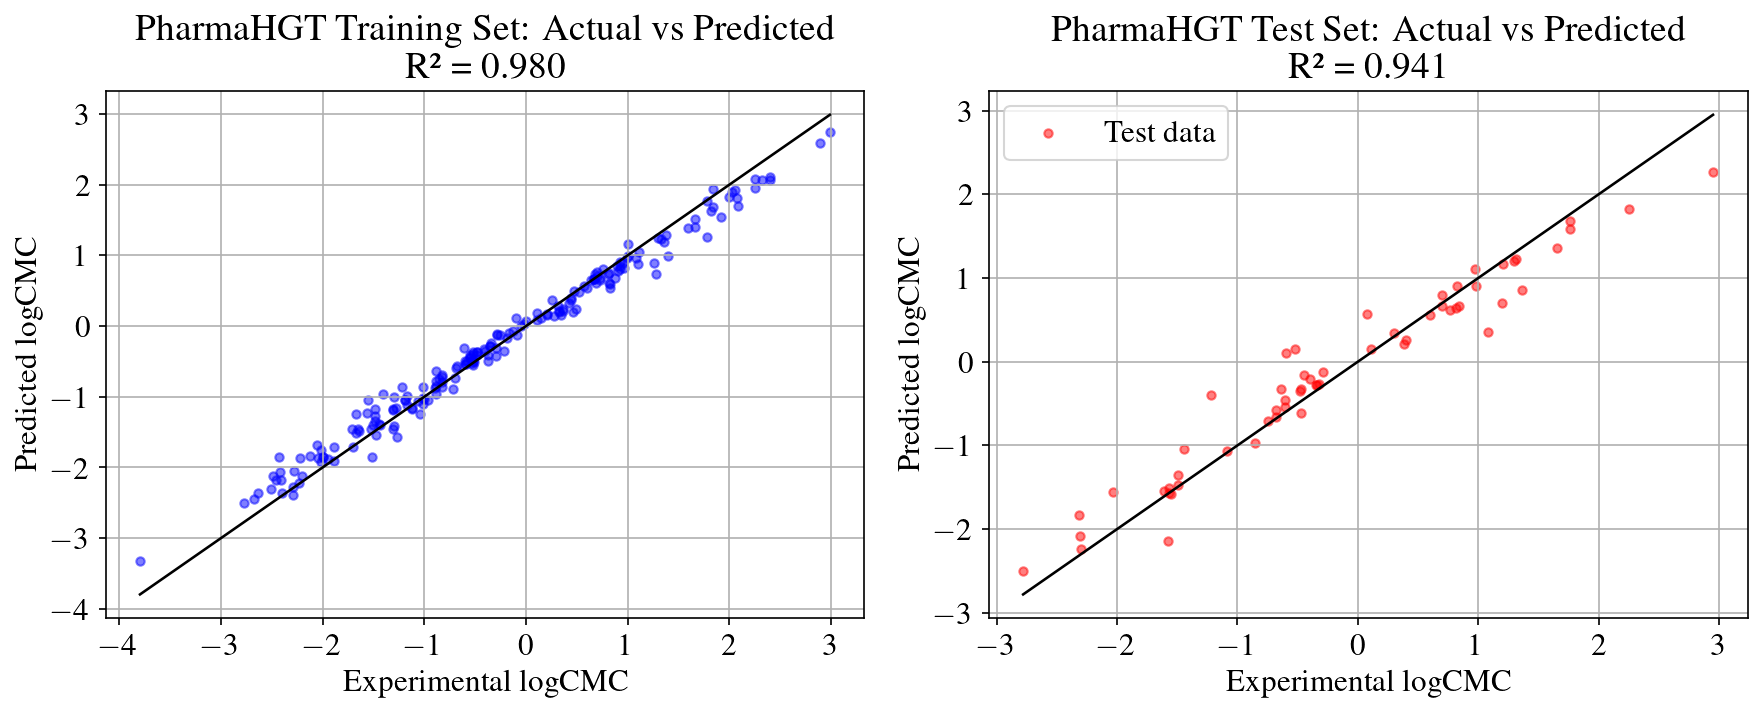

In [30]:
# Setup paths
base_dir = base_dir
model_dir = os.path.join(base_dir, 'models', model_folder)  # Directory for model
save_path = os.path.join(model_dir, 'results')  # Directory for results

# Create results directory
os.makedirs(save_path, exist_ok=True)

# Create plots
plt.figure(figsize=(12, 5))

# Training set plot
plt.subplot(1, 2, 1)
plt.scatter(train_true, train_pred, c='blue', alpha=0.5, label='Training data')
plt.plot([min(train_true), max(train_true)], [min(train_true), max(train_true)], 'black')
plt.xlabel('Experimental logCMC')
plt.ylabel('Predicted logCMC')
plt.title(f'PharmaHGT Training Set: Actual vs Predicted\nR² = {train_metrics[0]:.3f}')
plt.grid(True)

# Test set plot
plt.subplot(1, 2, 2)
plt.scatter(test_true, test_pred, color='red', alpha=0.5, label='Test data')
plt.plot([min(test_true), max(test_true)], [min(test_true), max(test_true)], 'black')
plt.xlabel('Experimental logCMC')
plt.ylabel('Predicted logCMC')
plt.title(f'PharmaHGT Test Set: Actual vs Predicted\nR² = {test_metrics[0]:.3f}')
plt.legend(loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(save_path, 'prediction_plots.png'))
plt.show()

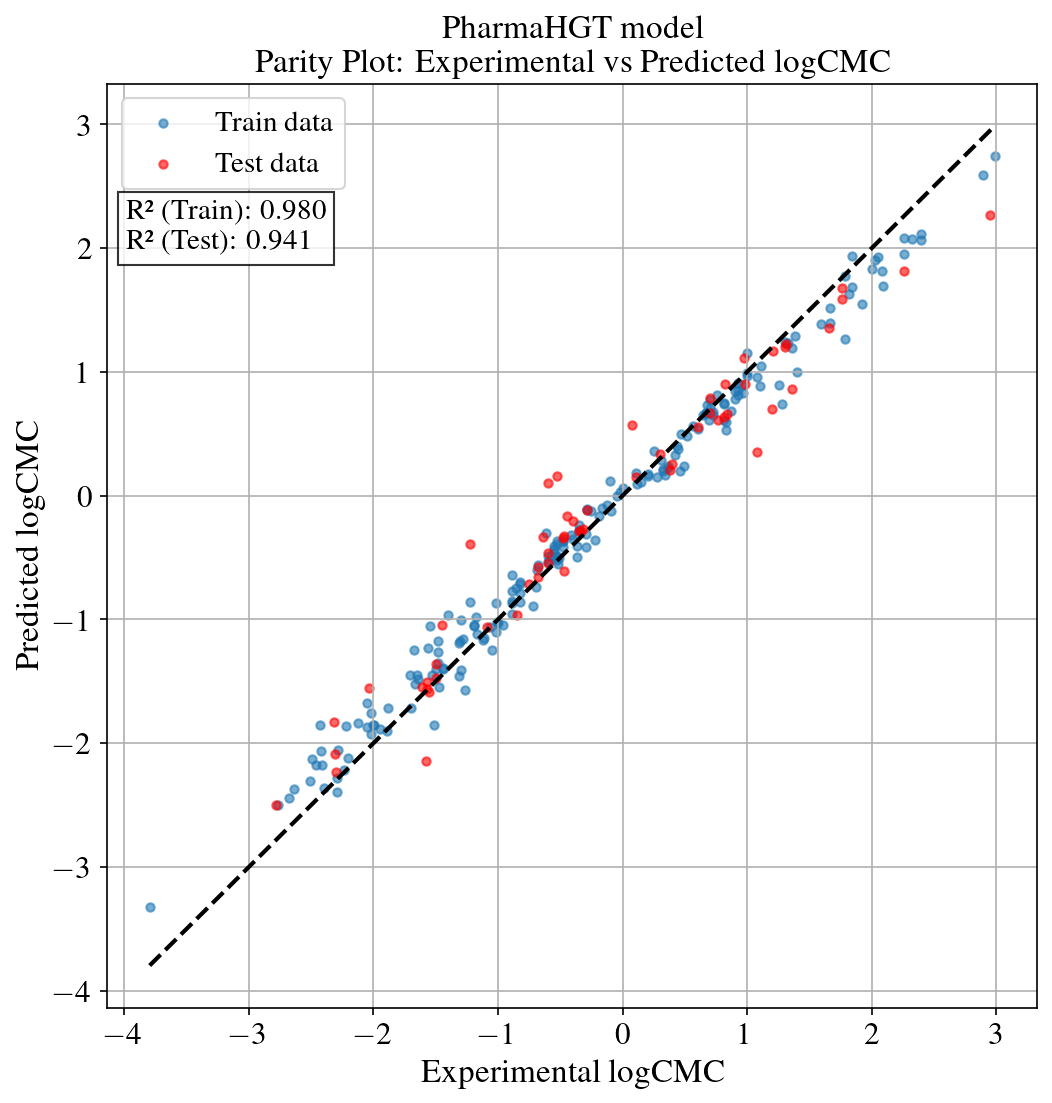

In [57]:
# Combined plot
plt.figure(figsize=(8, 8))
plt.scatter(train_true, train_pred, alpha=0.6, label='Train data')
plt.scatter(test_true, test_pred, alpha=0.6, color='red', label='Test data')
plt.plot([min(min(train_true), min(test_true)), max(max(train_true), max(test_true))], 
         [min(min(train_true), min(test_true)), max(max(train_true), max(test_true))], color='black', lw=2, linestyle='--')

# Add R² values as text in the plot
plt.text(0.02, 0.82, f'R² (Train): {train_metrics[0]:.3f}\nR² (Test): {test_metrics[0]:.3f}', 
         transform=plt.gca().transAxes, fontsize=14,
         bbox=dict(facecolor='white', alpha=0.8))

plt.xlabel('Experimental logCMC', fontsize=16)
plt.ylabel('Predicted logCMC', fontsize=16)
plt.title('PharmaHGT model \nParity Plot: Experimental vs Predicted logCMC', fontsize=16)
plt.legend(loc='upper left',fontsize=14)
plt.grid(True)
plt.savefig(os.path.join(save_path, 'combined_prediction_plot.png'),
            dpi=600,bbox_inches='tight')
plt.show()

In [68]:
def make_parity_plot_from_metrics(
    train_true,
    train_pred,
    test_true,
    test_pred,
    train_metrics,
    test_metrics,
    model_name,
    save_path,
    filename="parity_plot.png",
    lock_limits=False,
):
    """
    Make a parity plot (like the GCN one) using the variables you already have.
    train_metrics[0] and test_metrics[0] are R² in your code.
    """

    # base style
    plt.rcParams.update({
        "text.usetex": False,
        "font.family": "serif",
        "mathtext.fontset": "cm",
    })

    plt.figure(figsize=(8, 8))

    # scatter
    plt.scatter(train_true, train_pred, s=40, alpha=0.6, label='Train data')
    plt.scatter(test_true,  test_pred,  s=40, alpha=0.6, color='red', label='Test data')

    # diagonal
    # build it from the *true* values, like your other plot
    combined_true = np.concatenate([train_true, test_true])
    dmin = combined_true.min()
    dmax = combined_true.max()

    if lock_limits:
        plt.xlim(dmin, dmax)
        plt.ylim(dmin, dmax)

    plt.plot([dmin, dmax], [dmin, dmax],
             color='black', lw=2, linestyle='--')

    # R² values (they are at index 0 in your metrics tuple)
    train_r2 = train_metrics[0]
    test_r2  = test_metrics[0]

    plt.text(
        0.02, 0.82,
        f'R² (Train): {train_r2:.3f}\nR² (Test): {test_r2:.3f}',
        transform=plt.gca().transAxes,
        fontsize=14,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='black')
    )

    # labels / title
    plt.xlabel('Experimental logCMC', fontsize=16)
    plt.ylabel('Predicted logCMC', fontsize=16)
    plt.title(f'{model_name} model\nParity Plot: Experimental vs Predicted logCMC',
              fontsize=16)

    plt.legend(loc='upper left', fontsize=14)
    plt.grid(True)
    plt.tight_layout()

    os.makedirs(save_path, exist_ok=True)
    plt.savefig(os.path.join(save_path, filename),
                dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()

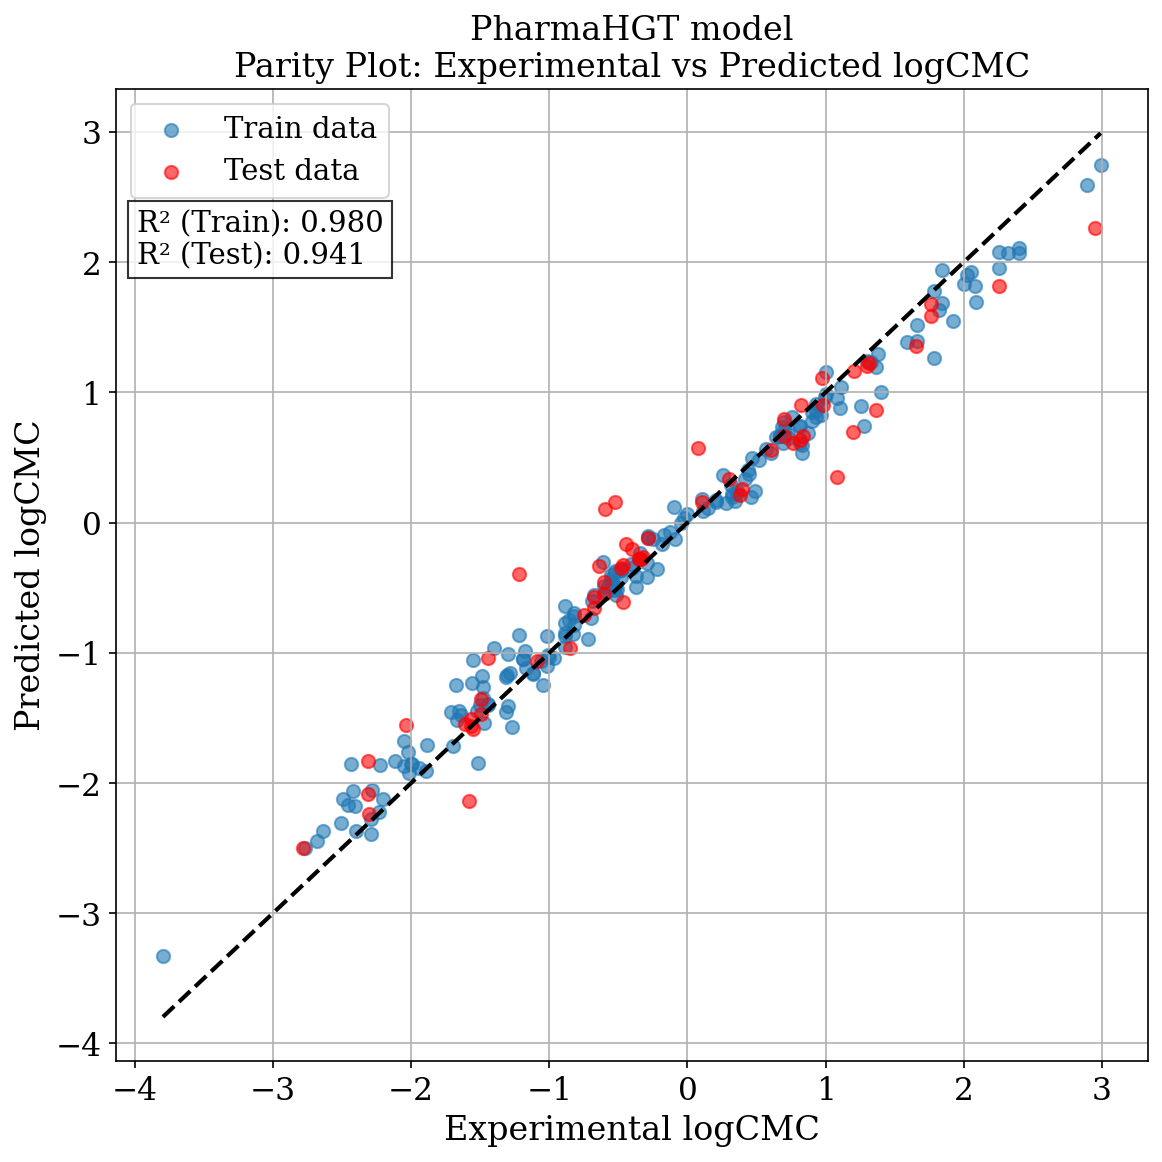

In [69]:
make_parity_plot_from_metrics(
    train_true=train_true,
    train_pred=train_pred,
    test_true=test_true,
    test_pred=test_pred,
    train_metrics=train_metrics,
    test_metrics=test_metrics,
    model_name="PharmaHGT",
    save_path=save_path,              # same folder you used before
    filename="parity_pharmahgt2.png",
    lock_limits=False                 # True if you want fixed axes
)

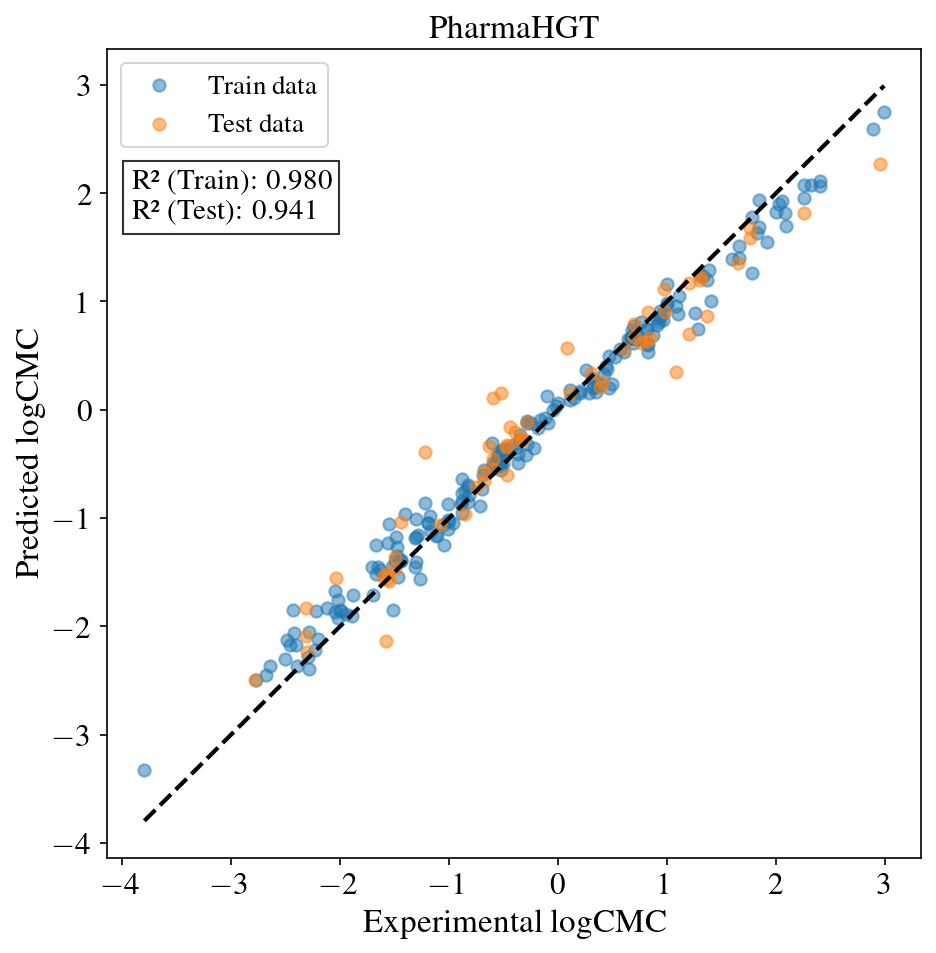

In [32]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

# Set global matplotlib settings
mpl.rcParams['lines.linewidth'] = 1.25  # Set line width
mpl.rcParams['lines.markersize'] = 4    # Set marker size
mpl.rcParams['figure.dpi'] = 150        # Set dpi

# Update rcParams for LaTeX and font settings
plt.rcParams.update({
    "text.usetex": True,  # Use LaTeX for rendering text
    "font.family": "serif",
    "font.sans-serif": ["Times"],
    "font.size": 15
})

# Combined plot
plt.figure(figsize=(7, 7))
plt.scatter(train_true, train_pred, s=35, alpha=0.5, label='Train data')
plt.scatter(test_true, test_pred, s=35, alpha=0.5, label='Test data')
plt.plot([min(min(train_true), min(test_true)), max(max(train_true), max(test_true))], 
         [min(min(train_true), min(test_true)), max(max(train_true), max(test_true))], color='black', lw=2, linestyle='--')

# Add R² values as text in the plot
plt.text(0.03, 0.79, f'R² (Train): {train_metrics[0]:.3f}\nR² (Test): {test_metrics[0]:.3f}', 
         transform=plt.gca().transAxes, fontsize=14,
         bbox=dict(facecolor='white', alpha=0.8))

plt.xlabel('Experimental logCMC', fontsize=16)
plt.ylabel('Predicted logCMC', fontsize=16)
plt.title('PharmaHGT', fontsize=16)
plt.legend(loc='upper left',fontsize=13)
# plt.grid(True)
plt.savefig(os.path.join(save_path, 'combined_prediction_plot_2Nogrid.png'))
plt.show()

In [33]:
# Save results to CSV
results = pd.DataFrame([
    [train_metrics[2], test_metrics[2], train_metrics[0], test_metrics[0],
     train_metrics[1], test_metrics[1], train_metrics[4], test_metrics[4]]
], columns=[
    'MSE (Train)', 'MSE (Test)', 'R^2 (Train)', 'R^2 (Test)',
    'MAE (Train)', 'MAE (Test)', 'Standard Deviation (Train)', 'Standard Deviation (Test)'
])
results.to_csv(os.path.join(save_path, 'metrics.csv'), index=False)

# Save predictions
train_predictions = pd.DataFrame({
    'True_Value': train_true.flatten(),
    'Predicted_Value': train_pred.flatten(),
    'Set': 'Train'
})

test_predictions = pd.DataFrame({
    'True_Value': test_true.flatten(),
    'Predicted_Value': test_pred.flatten(),
    'Set': 'Test'
})

predictions = pd.concat([train_predictions, test_predictions])
predictions.to_csv(os.path.join(save_path, 'predictions.csv'), index=False)

print(f"\nResults saved to: {save_path}")


Results saved to: c:\Users\gtheis2\git\surfactant_project\Graph-Transformers_org-2\models\surfactant_model_data1_newSplit70_20_10_plot_opt_R7/seed_42/fold_0\results


In [34]:
# First, let's get the original SMILES from the data files
train_data = pd.read_csv(os.path.join(data_args['path'], f'{ramdom_seed}_fold_0_train.csv'))
test_data = pd.read_csv(os.path.join(data_args['path'], f'{ramdom_seed}_fold_0_test.csv'))

# Function to get predictions
def get_predictions(loader):
    y_true = []
    y_pred = []
    
    model.eval()
    with torch.no_grad():
        for bg, labels in loader:
            bg = bg.to(device)
            outputs = model(bg)
            y_true.extend(labels.numpy())
            y_pred.extend(outputs.cpu().numpy())
            
    return np.array(y_true), np.array(y_pred)

# Get predictions
train_true, train_pred = get_predictions(trainloader)
test_true, test_pred = get_predictions(testloader)

# Create DataFrames with predictions and SMILES
train_predictions = pd.DataFrame({
    'SMILES': train_data['smiles'],  # Using original SMILES from CSV
    'True_Value': train_true.flatten(),
    'Predicted_Value': train_pred.flatten(),
    'Set': 'Train'
})

test_predictions = pd.DataFrame({
    'SMILES': test_data['smiles'],  # Using original SMILES from CSV
    'True_Value': test_true.flatten(),
    'Predicted_Value': test_pred.flatten(),
    'Set': 'Test'
})

# Add error calculations
for df in [train_predictions, test_predictions]:
    df['Absolute_Error'] = abs(df['True_Value'] - df['Predicted_Value'])
    df['Relative_Error'] = df['Absolute_Error'] / abs(df['True_Value'])

# Combine and sort by error
predictions = pd.concat([train_predictions, test_predictions])
predictions_sorted = predictions.sort_values('Absolute_Error', ascending=False)

# Save all versions
predictions_sorted.to_csv(os.path.join(save_path, 'predictions_with_smiles.csv'), index=False)
train_predictions.to_csv(os.path.join(save_path, 'train_predictions_with_smiles.csv'), index=False)
test_predictions.to_csv(os.path.join(save_path, 'test_predictions_with_smiles.csv'), index=False)

print(f"\nResults saved to: {save_path}")
print("\nTop 5 most challenging predictions:")
print(predictions_sorted[['SMILES', 'True_Value', 'Predicted_Value', 'Absolute_Error']].head())

# Additional summary statistics
print("\nSummary Statistics:")
for dataset in ['Train', 'Test']:
    subset = predictions[predictions['Set'] == dataset]
    print(f"\n{dataset} Set:")
    print(f"Mean Absolute Error: {subset['Absolute_Error'].mean():.4f}")
    print(f"Max Absolute Error: {subset['Absolute_Error'].max():.4f}")
    print(f"Mean Relative Error: {subset['Relative_Error'].mean():.4f}")
    print(f"Number of molecules: {len(subset)}")


Results saved to: c:\Users\gtheis2\git\surfactant_project\Graph-Transformers_org-2\models\surfactant_model_data1_newSplit70_20_10_plot_opt_R7/seed_42/fold_0\results

Top 5 most challenging predictions:
                                               SMILES  True_Value  \
56  CCCCCCCCCCCCC(=O)N(CCOCCOCCOCCOCCOCCOCCO)CCN(C...   -1.221849   
35                       CCCCCCCCOCC1OC(O)C(O)C(O)C1O    1.079181   
21  CCCCCCCCCCO[C@H]1O[C@H](CO)[C@@H](O)[C@H](O)[C...   -0.600326   
40                          CC(C)COCCOCCOCCOCCOCCOCCO    2.949878   
46                  CCCCCCCCOCCCCOCC1OC(O)C(O)C(O)C1O   -0.522879   

    Predicted_Value  Absolute_Error  
56        -0.393773        0.828076  
35         0.351025        0.728156  
21         0.105429        0.705755  
40         2.264908        0.684970  
46         0.156593        0.679472  

Summary Statistics:

Train Set:
Mean Absolute Error: 0.1437
Max Absolute Error: 0.5792
Mean Relative Error: inf
Number of molecules: 199

Test Set:
Mean 